# Nonlinear / Chaotic Graph Benchmarks vs Linear DMD

This notebook assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); here the stress test is
genuinely **nonlinear / chaotic graph dynamics** versus classical vector DMD.
Only one of the four systems is a PDE (Kuramoto–Sivashinsky); the rest are a
chaotic ODE, a networked epidemic, and a Hopf wake surrogate.

Most packaged KoopmanGraph tutorials train on **Laplacian diffusion plus forcing** —
dynamics that are already close to linear on the graph. Tutorial budgets here
(epochs, latent size, trajectory length) are intentionally short, so results are
**two-sided by design**. The question this library is meant to answer is:

> Under a fixed tutorial budget, when does topology-aware GraphKoopman beat
> linear DMD—and when does it not?

This notebook runs that comparison on four packaged nonlinear benchmarks:

1. **Kuramoto–Sivashinsky (KS)** — chaotic 1D PDE; used as a hard nonlinear example
   in EDMD with dictionary learning (Li et al., 2017, *Chaos*)
2. **Lorenz-96** — chaotic ODE on a periodic ring (Lorenz, 1996); coupling matches
   the graph used here
3. **Networked SIR** — nonlinear epidemic force-of-infection on a contact ring
4. **Cylinder-wake Hopf surrogate** — cached Stuart–Landau / POD teaching mesh
   (reduced-order wake motif; **not** Navier–Stokes DNS)

The baseline here is **linear** `DMDBaseline` (flattened node states). For these
nonlinear systems, `EDMDBaseline` with a richer dictionary is the natural stronger
classical peer; this notebook keeps the comparison apples-to-apples and minimal.

The goal is **not** a leaderboard claim. It is to demonstrate the datasets, show a
matched GraphKoopman vs DMD evaluation, and interpret when graph structure helps.


## Method: matched GraphKoopman vs DMD protocol

Same chronological `temporal_split` and multi-origin RMSE for `GraphKoopmanModel`
and `DMDBaseline` across four packaged nonlinear benchmarks. Not a leaderboard
claim — an apples-to-apples demonstration of when graph structure helps.

The classical baseline is deliberately linear DMD. A follow-up with
`EDMDBaseline` (or a larger GraphKoopman budget) is a natural next experiment when
you want a stronger nonlinear classical reference.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.baselines import DMDBaseline
from koopman_graph.data import temporal_split
from koopman_graph.datasets import (
    CylinderWakeBenchmark,
    EpidemicNetworkBenchmark,
    KuramotoSivashinskyBenchmark,
    Lorenz96GraphBenchmark,
)

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Model / training hyperparameters (CI uses a smaller smoke budget)
HIDDEN = 16 if CI else 32
LATENT = 12 if CI else 24
EPOCHS = 4 if CI else 40
LR = 1e-3
WINDOW_SEED = SEED

# Per-system integration / snapshot time steps
KS_DT = 0.25
L96_DT = 0.05 if CI else 0.01
SIR_DT = 1.0
WAKE_DT = 0.15

# Multi-origin evaluation horizons
KS_HORIZONS = (2, 4) if CI else (3, 6, 12)
L96_HORIZONS = (2, 4) if CI else (5, 10, 20)
SIR_HORIZONS = (2, 4) if CI else (3, 6, 12)
WAKE_HORIZONS = (2, 4) if CI else (3, 6, 12)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "font.size": 10,
    }
)


## Helper functions

Multi-origin RMSE and fit/compare utilities shared across the four systems.


In [2]:
def multi_origin_rmse(predict_fn, test_seq, horizons: tuple[int, ...]) -> dict[int, float]:
    # RMSE averaged over all valid origins and lead times within each horizon.
    scores: dict[int, float] = {}
    for horizon in horizons:
        sq_errors: list[torch.Tensor] = []
        max_origin = test_seq.num_timesteps - horizon
        if max_origin <= 0:
            scores[horizon] = float("nan")
            continue
        for origin in range(0, max_origin):
            preds = predict_fn(test_seq[origin], horizon)
            for step in range(horizon):
                sq_errors.append((preds[step].x - test_seq[origin + 1 + step].x).pow(2))
        scores[horizon] = float(torch.stack(sq_errors).mean().sqrt())
    return scores


def fit_compare(
    name: str,
    sequence,
    *,
    time_step: float,
    horizons: tuple[int, ...],
) -> dict[str, object]:
    # Train GraphKoopman + DMD and return structured multi-origin RMSE results.
    split = temporal_split(sequence, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2)
    in_channels = sequence.in_channels
    torch.manual_seed(SEED)
    model = GraphKoopmanModel(
        encoder=GNNEncoder(in_channels, HIDDEN, LATENT, num_layers=2),
        decoder=GNNDecoder(LATENT, HIDDEN, in_channels, num_layers=2),
        latent_dim=LATENT,
        time_step=time_step,
        koopman_parameterization="schur",
    )
    model.fit(split.train, epochs=EPOCHS, lr=LR, window_seed=WINDOW_SEED)
    dmd = DMDBaseline(time_step=time_step).fit(split.train)
    graph_rmses = multi_origin_rmse(
        lambda snapshot, horizon: model.predict(snapshot, steps=horizon),
        split.test,
        horizons,
    )
    dmd_rmses = multi_origin_rmse(
        lambda snapshot, horizon: dmd.predict(snapshot, steps=horizon),
        split.test,
        horizons,
    )
    print(f"\n{name}")
    print(f"{'horizon':>8} {'GraphKoopman':>14} {'DMD':>10}")
    for horizon in horizons:
        print(f"{horizon:>8} {graph_rmses[horizon]:>14.4f} {dmd_rmses[horizon]:>10.4f}")
    return {
        "name": name,
        "horizons": horizons,
        "graph": graph_rmses,
        "dmd": dmd_rmses,
        "split": split,
        "sequence": sequence,
    }


## Generate the four nonlinear systems

Kuramoto–Sivashinsky (PDE), Lorenz-96 (ODE), networked SIR, and a cylinder-wake
Hopf surrogate. Compact governing forms used by the packaged generators:

**Kuramoto–Sivashinsky** (periodic 1D; domain length $L=22$ here):

$$
\partial_t u + \partial_{xx} u + \partial_{xxxx} u + \tfrac{1}{2}\partial_x(u^2) = 0
$$

**Lorenz-96** (ring of $N$ variables; forcing $F=8$):

$$
\dot{x}_i = (x_{i+1} - x_{i-2})\,x_{i-1} - x_i + F
$$

**Networked SIR** (discrete time; row-normalized neighbor force-of-infection):

$$
\begin{aligned}
I_i &\leftarrow I_i + \beta S_i \langle I \rangle_{\mathrm{nbr}(i)} - \gamma I_i, \\
R_i &\leftarrow R_i + \gamma I_i, \\
S_i &\leftarrow 1 - I_i - R_i
\end{aligned}
$$

**Cylinder-wake surrogate:** Stuart–Landau amplitude dynamics modulating cached
spatial modes on a wake mesh (teaching data, not CFD).


In [3]:
ks = KuramotoSivashinskyBenchmark.generate(
    num_nodes=32 if CI else 64,
    num_timesteps=60 if CI else 300,
    burn_in=20 if CI else 80,
    domain_length=22.0,
    dt=KS_DT,
    topology="ring",
    seed=SEED,
)
l96 = Lorenz96GraphBenchmark.generate(
    num_nodes=12 if CI else 40,
    num_timesteps=80 if CI else 400,
    burn_in=20 if CI else 150,
    forcing=8.0,
    dt=L96_DT,
    seed=SEED,
)
sir = EpidemicNetworkBenchmark.generate(
    num_nodes=16 if CI else 36,
    num_timesteps=30 if CI else 80,
    topology="ring",
    seed=SEED,
)
wake = CylinderWakeBenchmark.load_sequence()
if CI:
    wake = wake.slice(0, 40)

systems = {
    "Kuramoto–Sivashinsky": ks,
    "Lorenz-96": l96,
    "Networked SIR": sir,
    "Cylinder-wake surrogate": wake,
}
for name, seq in systems.items():
    print(
        f"{name:24s}  T={seq.num_timesteps:4d}  N={seq.num_nodes:3d}  "
        f"F={seq.in_channels}"
    )


Kuramoto–Sivashinsky      T= 300  N= 64  F=1
Lorenz-96                 T= 400  N= 40  F=1
Networked SIR             T=  80  N= 36  F=3
Cylinder-wake surrogate   T= 120  N= 72  F=1


### Snapshot of the dynamics

A quick look at each field before training: KS and Lorenz-96 should look irregular;
SIR shows a **spatial** infected front traveling around the ring (plus the usual
mean S/I/R epidemic curve is omitted here so the wave is visible); the wake
surrogate is a smooth, growing oscillation.


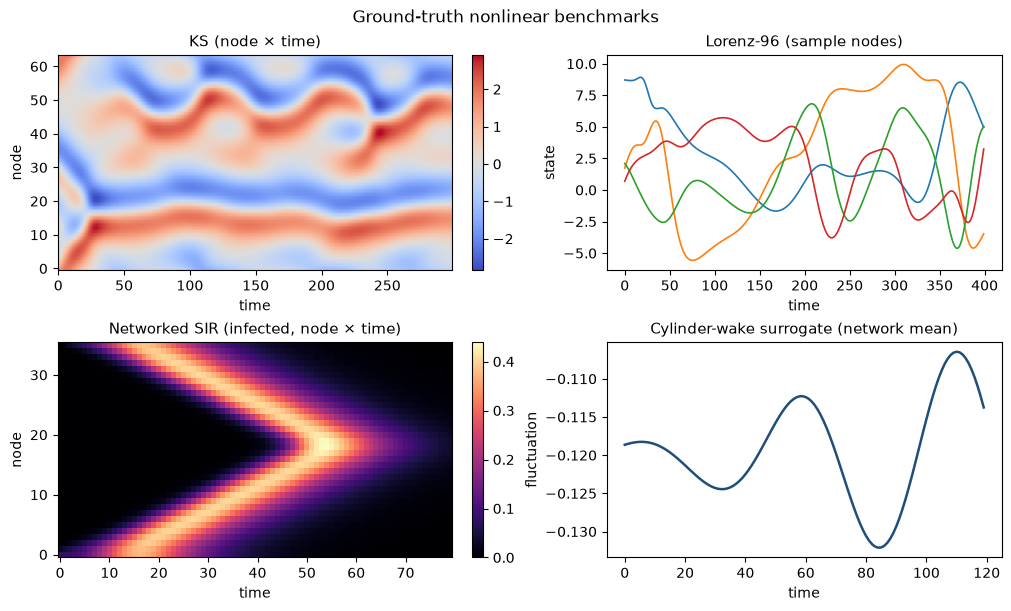

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)

# KS spacetime strip (node × time for channel 0)
ks_field = torch.stack([snap.x[:, 0] for snap in ks], dim=1).numpy()
im0 = axes[0, 0].imshow(ks_field, aspect="auto", cmap="coolwarm", origin="lower")
axes[0, 0].set_title("KS (node × time)")
axes[0, 0].set_xlabel("time")
axes[0, 0].set_ylabel("node")
fig.colorbar(im0, ax=axes[0, 0], fraction=0.046)

# Lorenz-96: a few node trajectories
for node in range(min(4, l96.num_nodes)):
    axes[0, 1].plot([float(l96[t].x[node, 0]) for t in range(l96.num_timesteps)], lw=1.2)
axes[0, 1].set_title("Lorenz-96 (sample nodes)")
axes[0, 1].set_xlabel("time")
axes[0, 1].set_ylabel("state")

# SIR: infected fraction over the ring (spatial traveling front)
sir_I = torch.stack([snap.x[:, 1] for snap in sir], dim=1).numpy()
im1 = axes[1, 0].imshow(sir_I, aspect="auto", cmap="magma", origin="lower", vmin=0.0)
axes[1, 0].set_title("Networked SIR (infected, node × time)")
axes[1, 0].set_xlabel("time")
axes[1, 0].set_ylabel("node")
fig.colorbar(im1, ax=axes[1, 0], fraction=0.046)

# Wake: network-mean fluctuation
wake_mean = [float(snap.x.mean()) for snap in wake]
axes[1, 1].plot(wake_mean, color="#1f4e79", lw=1.8)
axes[1, 1].set_title("Cylinder-wake surrogate (network mean)")
axes[1, 1].set_xlabel("time")
axes[1, 1].set_ylabel("fluctuation")

fig.suptitle("Ground-truth nonlinear benchmarks", fontsize=12)
plt.show()


## Train and evaluate

Fit GraphKoopman and DMD under the shared protocol for each system.


In [5]:
results = [
    fit_compare(
        "Kuramoto–Sivashinsky",
        ks,
        time_step=KS_DT,
        horizons=KS_HORIZONS,
    ),
    fit_compare(
        "Lorenz-96",
        l96,
        time_step=L96_DT,
        horizons=L96_HORIZONS,
    ),
    fit_compare(
        "Networked SIR",
        sir,
        time_step=SIR_DT,
        horizons=SIR_HORIZONS,
    ),
    fit_compare(
        "Cylinder-wake surrogate",
        wake,
        time_step=WAKE_DT,
        horizons=WAKE_HORIZONS,
    ),
]



Kuramoto–Sivashinsky
 horizon   GraphKoopman        DMD
       3         0.5250     0.1761
       6         1.0216     0.3153
      12         1.9689     0.5949

Lorenz-96
 horizon   GraphKoopman        DMD
       5         4.4447    10.6597
      10         6.6101    17.5670
      20        10.5714    27.6060

Networked SIR
 horizon   GraphKoopman        DMD
       3         0.0705     0.0091
       6         0.1931     0.0163
      12         0.4614     0.0315

Cylinder-wake surrogate
 horizon   GraphKoopman        DMD
       3         0.1377     0.0053
       6         0.1816     0.0095
      12         0.3406     0.0181


## Results

Multi-origin RMSE tables and **RMSE versus forecast horizon** curves for each
benchmark (GraphKoopman vs vector DMD on matched axes per system).


system                     GraphKoopman        DMD   Δ (GK−DMD)
----------------------------------------------------------------
Kuramoto–Sivashinsky             1.1718     0.3621       0.8097
Lorenz-96                        7.2087    18.6109     -11.4022
Networked SIR                    0.2417     0.0190       0.2227
Cylinder-wake surrogate          0.2200     0.0110       0.2090


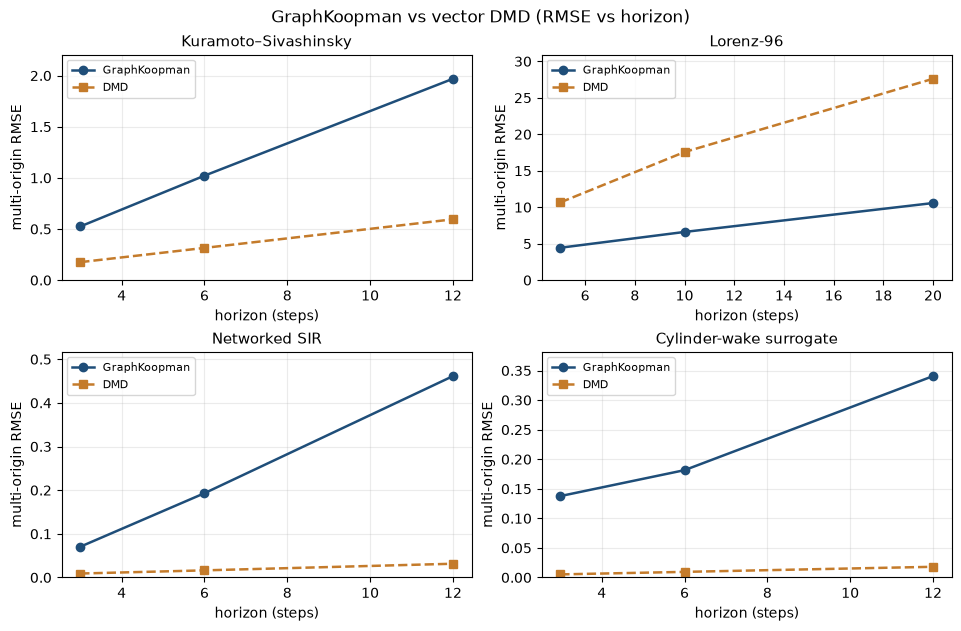

In [6]:
print(f"{'system':26s} {'GraphKoopman':>12} {'DMD':>10} {'Δ (GK−DMD)':>12}")
print("-" * 64)
for item in results:
    horizons = item["horizons"]
    g_mean = sum(item["graph"][h] for h in horizons) / len(horizons)
    d_mean = sum(item["dmd"][h] for h in horizons) / len(horizons)
    print(f"{item['name']:26s} {g_mean:12.4f} {d_mean:10.4f} {g_mean - d_mean:12.4f}")

fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.2), constrained_layout=True)
for ax, item in zip(axes.ravel(), results, strict=True):
    horizons = list(item["horizons"])
    g_vals = [item["graph"][h] for h in horizons]
    d_vals = [item["dmd"][h] for h in horizons]
    ax.plot(horizons, g_vals, "o-", color="#1f4e79", lw=1.8, label="GraphKoopman")
    ax.plot(horizons, d_vals, "s--", color="#c47b2b", lw=1.8, label="DMD")
    ax.set_title(item["name"])
    ax.set_xlabel("horizon (steps)")
    ax.set_ylabel("multi-origin RMSE")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="best")
    ymax = max(max(g_vals), max(d_vals))
    ax.set_ylim(0.0, ymax * 1.12 if ymax > 0 else 1.0)

fig.suptitle(
    "GraphKoopman vs vector DMD (RMSE vs horizon)",
    fontsize=12,
)
plt.show()


## Interpret the results

Reading the horizon curves (and the mean Δ table) under this fixed tutorial budget:

- **Lorenz-96:** GraphKoopman wins at every reported horizon. Nearest-neighbor
  coupling in the ODE matches the ring graph, so topology-aware lifting has a
  clear job to do against flattened linear DMD.
- **Kuramoto–Sivashinsky:** DMD stays ahead. KS is genuinely chaotic, but the
  short trajectory / modest latent / 40-epoch budget is a hard setting for a
  learned lift; linear DMD on the grid can still look strong at these horizons.
- **Networked SIR:** DMD wins by a large margin. The ring epidemic front is
  nonlinear, yet the short held-out window is smooth enough that a linear map on
  flattened $(S,I,R)$ states forecasts well.
- **Cylinder-wake surrogate:** DMD dominates, as expected for a nearly linear
  Hopf / Stuart–Landau teaching motif.

So the notebook’s claim is two-sided on purpose: graph structure helps when
coupling and nonlinearity align with the message-passing graph (Lorenz-96 here);
nearly linear surrogates and short chaotic budgets can still favor DMD.


## Takeaways

- **Goal revisited:** we can now stress-test topology-aware Koopman models on
  packaged nonlinear / chaotic graph dynamics instead of only linear diffusion.
- **Protocol:** same chronological split and multi-origin RMSE for
  `GraphKoopmanModel` and linear `DMDBaseline`.
- **Datasets:** `KuramotoSivashinskyBenchmark`, `Lorenz96GraphBenchmark`,
  `EpidemicNetworkBenchmark`, and cached `CylinderWakeBenchmark` live in
  `koopman_graph.datasets`.
- **Interpretation:** GraphKoopman is most compelling when graph coupling and
  nonlinearity matter (Lorenz-96 here); nearly linear surrogates and short
  chaotic budgets can favor DMD — report both sides.
- **Classical peer:** this demo uses linear DMD for a minimal matched baseline;
  try `EDMDBaseline` when you want a stronger nonlinear classical reference.
- **Next steps:** increase epochs / latent size in a fuller demo for research plots;
  see notebook 06 for a visual SIR showcase on the ring.

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the base workflow on near-linear dynamics.
- See [`06_epidemic_ring.ipynb`](06_epidemic_ring.ipynb) for a visual SIR showcase on the ring.
- See [`22_gnn_forecaster_comparison.ipynb`](22_gnn_forecaster_comparison.ipynb) for METR-LA vs nonlinear GNN baselines.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
